# Paper figures with public ADME data

---

Reproduces the main-text figures of the "Uncertainty quantification in molecular machine learning for property predictions under data shifts" manuscript that rely on the public ADME dataset (Figures 2 and 3).

The notebook expects that the UNIQUE pipeline has already been executed for each endpoint (see `scripts/run_unique.py`) so that the corresponding `{model_id}_uq_metrics_values.csv` input file exist under `unique_output/{model_id}/`.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

from sklearn.metrics import mean_absolute_error

import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

seed = 42

In [2]:
# Define the endpoints dictionary
endpoints_dict = {'clint': {'rLM LogCLint':'clint_rat', 'hLM LogCLint':'clint_human'},
                  'ppb': {'LogFu-Rat':'ppb_rat', 'LogFu-Human':'ppb_human'},
                  'mdr1': {'MDCK-MDR1_LogER':'mdck_mdr1_er'}}

## Figure 2

In [3]:
# Define the main UQ methods we want to compare
main_uq_methods = ['ManhattanDistance[latent_fp_scaled]','EnsembleVariance[variance]','UniqueRandomForestRegressor[UQmetrics+predictions](l1)']
uq_methods_sets = {'manuscript': ['Baseline','ManhattanDistance[latent_fp_scaled]','EnsembleVariance[variance]','UniqueRandomForestRegressor[UQmetrics+predictions](l1)']}

In [4]:
bs_results = {}
best_methods = {}

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')
        bs_results[model_name] = {}
        best_methods[model_name] = {}

        # Load UNIQUE input data
        input_data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv', index_col=0).reset_index(drop=True)
        print(input_data.shape)
        # Load UQ metrics values
        uq_metrics_data = pd.read_csv(f'unique_output/{model_id}/{model_id}_uq_metrics_values.csv')
        print(uq_metrics_data.shape)

        # Create the DataFrame to perform bootstrapping
        bs_df = pd.concat([input_data[['Id','labels','predictions','which_set']],  uq_metrics_data[main_uq_methods]], axis=1)
        print(bs_df.shape)

        # Select TEST data
        bs_df_test = bs_df.loc[bs_df.which_set == 'TEST'].reset_index(drop=True)
        print(bs_df_test.shape)

        # Build the bootstrap samples datasets
        replicas_dict = {"uq_values": [], "predictions": [], "labels": []}
        n_bootstrap = n_perm = 100
        np.random.seed(seed)

        for _ in range(n_bootstrap):
            # sampling with replacement with # samples = N
            sample_indices = np.random.choice(len(bs_df_test), size=len(bs_df_test))
            replicas_dict["uq_values"].append(bs_df_test.iloc[sample_indices][main_uq_methods])
            replicas_dict["predictions"].append(bs_df_test.predictions[sample_indices])
            replicas_dict["labels"].append(bs_df_test.labels[sample_indices])

        # Calculate Spearman correlation for each bootstrap sample across all UQ methods
        for uq_method in main_uq_methods:
            spearman_values = []
            for n in range(n_bootstrap):
                uq_values = replicas_dict["uq_values"][n][uq_method]
                spearman = stats.spearmanr(np.abs(replicas_dict["predictions"][n] - replicas_dict["labels"][n]), uq_values)[0]
                spearman_values.append(spearman)

            bs_results[model_name][uq_method] = spearman_values

        # Compute the permutation baseline
        true_error = np.abs(bs_df_test["predictions"] - bs_df_test["labels"])
        permuted_baseline = []
        for _ in range(n_perm):
            permuted_true_error = np.random.permutation(true_error)
            spearman = stats.spearmanr(true_error, permuted_true_error)[0]
            permuted_baseline.append(spearman)

        bs_results[model_name]['Baseline'] = permuted_baseline

        for set_name, uq_methods_set in uq_methods_sets.items():

            # Perform pairwise comparisons using Wilcoxon signed-rank test
            comparisons = list(itertools.combinations(uq_methods_set, 2))
            wilcoxon_results = []
            for method1, method2 in comparisons:
                data1 = np.array(bs_results[model_name][method1])
                data2 = np.array(bs_results[model_name][method2])
                differences = data1 - data2

                # Check if all differences are zero
                if np.all(differences == 0):
                    p_value = 1.0
                else:
                    _, p_value = wilcoxon(differences)

                mean_diff = np.mean(data1) - np.mean(data2)
                wilcoxon_results.append((method1, method2, mean_diff, p_value))

            wilcoxon_df = pd.DataFrame(wilcoxon_results, columns=["group1", "group2", "meandiff", "p"])

            # Multiple testing correction
            reject, p_values_corrected, _, _ = multipletests(wilcoxon_df["p"].values, alpha=0.05, method="fdr_bh")
            wilcoxon_df["p_adj"] = p_values_corrected
            wilcoxon_df["reject"] = reject

            # Compute method scores based on pairwise comparison results
            method_scores = {method: 0 for method in uq_methods_set}
            for _, row in wilcoxon_df.iterrows():
                method1, method2, mean_diff, p_value, p_adj, reject = row
                if reject:  # Only consider if the result is statistically significant
                    if mean_diff > 0:
                        method_scores[method1] += 1
                    elif mean_diff < 0:
                        method_scores[method2] += 1

            # Select the best method based on the highest score
            best_method = [method for method, score in method_scores.items() if score == max(method_scores.values())]

            # Check if the best method is significant
            wilcoxon_filtered = wilcoxon_df.loc[(wilcoxon_df['group1'].eq(best_method[0]) | wilcoxon_df['group2'].eq(best_method[0])), :]
            is_best_different = []
            for _, row in wilcoxon_filtered.iterrows():
                method1, method2, _, _, _, reject = row
                is_best_different.append({'method': method1 if best_method[0] != method1 else method2, 'is_best_significant': reject})

            is_best_different_df = pd.DataFrame(is_best_different)

            best_methods[model_name][set_name] = [best_method[0]] + is_best_different_df['method'].loc[is_best_different_df.is_best_significant == False].tolist()


### clint ###


### rLM LogCLint ###

(3051, 7)
(3051, 12)
(3051, 7)
(609, 7)

### hLM LogCLint ###

(3084, 7)
(3084, 12)
(3084, 7)
(616, 7)

### ppb ###


### LogFu-Rat ###

(167, 7)
(167, 12)
(167, 7)
(32, 7)

### LogFu-Human ###

(193, 7)
(193, 12)
(193, 7)
(39, 7)

### mdr1 ###


### MDCK-MDR1_LogER ###

(2639, 7)
(2639, 12)
(2639, 7)
(527, 7)


In [5]:
# Generate the Pandas DataFrame to build the boxplots
boxplots_df = pd.DataFrame()
for endpoint, inner_dict in bs_results.items():
    for uq_method, spearman_values in inner_dict.items():
        tmp_df = pd.DataFrame({'endpoint': endpoint, 'uq_method': uq_method, 'eval_metric': spearman_values})
        boxplots_df = pd.concat([boxplots_df, tmp_df], ignore_index=True)

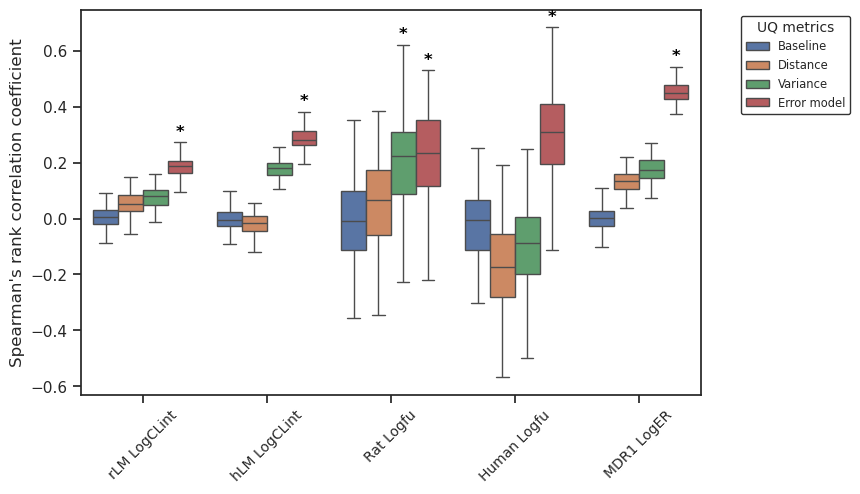

In [6]:
# Rename UQ methods' names
uq_methods_display_names = {'ManhattanDistance[latent_fp_scaled]': 'Distance',
                            'EnsembleVariance[variance]': 'Variance',
                            'UniqueRandomForestRegressor[UQmetrics+predictions](l1)': 'Error model',
                            'Baseline': 'Baseline'}
# Select endpoints
endpoints = ['rLM LogCLint','hLM LogCLint','LogFu-Rat','LogFu-Human','MDCK-MDR1_LogER']
endpoint_names = ['rLM LogCLint','hLM LogCLint','Rat Logfu','Human Logfu','MDR1 LogER']

# Plot the figure
for set_name in uq_methods_sets.keys():
    if set_name == 'manuscript':
        plt.figure(figsize=(8, 5))
        ax = sns.boxplot(data=boxplots_df, x="endpoint", y="eval_metric", hue="uq_method",
                         order=endpoints, hue_order=uq_methods_sets[set_name], linewidth=1, fliersize=3, showfliers=False)
        plt.ylabel('Spearman\'s rank correlation coefficient')
        plt.xlabel('')
        plt.xticks(ticks=ax.get_xticks(), labels=endpoint_names, fontsize=10, rotation=45)

        # add '*' label to the best method for each endpoint
        boxplot_width = 0.8
        n_methods = len(uq_methods_sets[set_name])
        each_width = boxplot_width / n_methods
        for endpoint in endpoints:
            for best_method in best_methods[endpoint][set_name]:
                # Get endpoint and method indexes and compute the x-coordinate
                endpoint_index = endpoints.index(endpoint)
                method_index = uq_methods_sets[set_name].index(best_method)
                x_coord = endpoint_index + (method_index - (n_methods - 1) / 2) * each_width
                # Compute the y-coordinate
                values = boxplots_df['eval_metric'].loc[(boxplots_df.endpoint == endpoint) & (boxplots_df.uq_method == best_method)].values
                q1, q3 = np.percentile(values, [25, 75])
                iqr = q3 - q1
                upper_whisker = values[values <= q3 + 1.5 * iqr].max()
                y_coord = upper_whisker + 0.01
                # Add the '*' text label at the computed coordinates
                ax.text(x=x_coord, y=y_coord, s='*', ha='center', va='bottom', fontsize=12, color='black', weight='semibold')

        # rename UQ methods
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [uq_methods_display_names[label] for label in labels]
        plt.legend(handles, new_labels, loc='upper right', bbox_to_anchor=(1.25, 1),
                   fontsize='x-small', title='UQ metrics', title_fontsize='small',
                   frameon=True, fancybox=True, facecolor='white', edgecolor='black')
        plt.show()

## Figure 3

In [7]:
mae_overall_df = pd.DataFrame(columns=['Endpoint','% Data','MAE','Addition Order'])

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')

        # Load UNIQUE input data
        data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv', index_col=0).reset_index(drop=True)
        print(data.shape)
        # Load UQ metrics values
        uq_metrics_data = pd.read_csv(f'unique_output/{model_id}/{model_id}_uq_metrics_values.csv')
        print(uq_metrics_data.shape)

        # Aggregate selected variables
        df = pd.concat([data[['Id','labels','predictions','which_set']], 
                        uq_metrics_data[['UniqueRandomForestRegressor[UQmetrics+predictions](l1)']]], axis=1)
        print(df.shape)
        # Rename columns
        df = df.rename(columns={'UniqueRandomForestRegressor[UQmetrics+predictions](l1)': 'EM_uncertainty'})

        # Select test data
        test_data = df[df['which_set'] == 'TEST']
        print(test_data.shape)

        mae_values = []
        for sorting_direction in [False, True]:
            addition_order = 'From high to low uncertainty' if sorting_direction == False else 'From low to high uncertainty'

            # Sort test data by the EM uncertainty values
            sorted_data = test_data.sort_values(by=['EM_uncertainty'], ascending=sorting_direction)

            for percent_mols in np.arange(10, 110, 10):
                # Select data
                subset_data = sorted_data.iloc[:int(len(sorted_data) * (percent_mols/100))]
                # Calculate the Mean Absolute Error
                mae = mean_absolute_error(subset_data['labels'], subset_data['predictions'])
                mae_values.append([percent_mols, mae, addition_order])

        mae_df = pd.DataFrame(data=mae_values, columns=['% Data','MAE','Addition Order'])
        mae_df['Endpoint'] = model_name

        mae_overall_df = pd.concat([mae_overall_df, mae_df], ignore_index=True)


### clint ###


### rLM LogCLint ###

(3051, 7)
(3051, 12)
(3051, 5)
(609, 5)

### hLM LogCLint ###



/tmp/ipykernel_585497/2599098672.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mae_overall_df = pd.concat([mae_overall_df, mae_df], ignore_index=True)


(3084, 7)
(3084, 12)
(3084, 5)
(616, 5)

### ppb ###


### LogFu-Rat ###

(167, 7)
(167, 12)
(167, 5)
(32, 5)

### LogFu-Human ###

(193, 7)
(193, 12)
(193, 5)
(39, 5)

### mdr1 ###


### MDCK-MDR1_LogER ###

(2639, 7)
(2639, 12)
(2639, 5)
(527, 5)


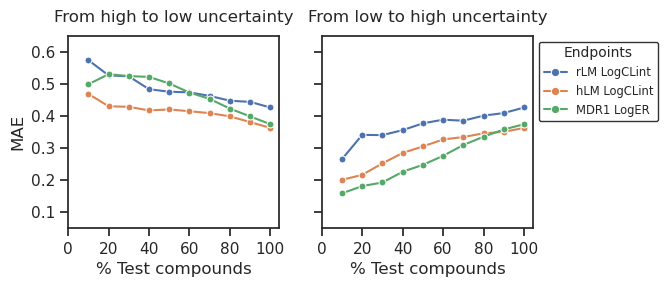

In [8]:
# Define the endpoints list
endpoints_list = ['rLM LogCLint','hLM LogCLint','MDCK-MDR1_LogER']
endpoint_names = ['rLM LogCLint','hLM LogCLint','MDR1 LogER']

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

# Subplots
for i, addition_order in enumerate(mae_overall_df['Addition Order'].unique()):
    plot_data = mae_overall_df.loc[mae_overall_df['Addition Order'] == addition_order]

    if i == 0:
        plot = sns.lineplot(data=plot_data, x='% Data', y='MAE', hue='Endpoint', hue_order=endpoints_list,
                            ax=axes[i], legend=False, marker='o')
    else:
        plot = sns.lineplot(data=plot_data, x='% Data', y='MAE', hue='Endpoint', hue_order=endpoints_list,
                            ax=axes[i], legend=True, marker='o')
        handles, _ = plot.get_legend_handles_labels()
        axes[i].legend(handles=handles, labels=endpoint_names, loc='best', bbox_to_anchor=(1, 1),
                       fontsize='x-small', title='Endpoints', title_fontsize='small',
                       frameon=True, fancybox=True, facecolor='white', edgecolor='black')

    for line in axes[i].lines:
        line.set_markersize(5)

    axes[i].set_xticks(np.arange(0, 110, step=20))
    axes[i].set_ylim(0.05, 0.65)
    axes[i].set_xlabel('% Test compounds')
    axes[i].set_ylabel('MAE')
    axes[i].set_title(addition_order, pad=10)

plt.show()